# Customer Churn Prediction

## Project Overview

Customer churn is a critical business challenge for subscription-based organizations, directly impacting customer lifetime value, recurring revenue, and acquisition costs. Early identification of customers at risk of churning enables businesses to implement targeted retention strategies and improve long-term profitability.

This project develops an end-to-end machine learning pipeline to predict customer churn using the **IBM Telco Customer Churn dataset**. The workflow includes data preprocessing, missing value treatment, categorical feature encoding, numerical feature scaling, and class imbalance handling using SMOTE to ensure robust model training.

Three supervised machine learning algorithms—Logistic Regression, Random Forest, and XGBoost—are trained and systematically evaluated using **Accuracy, Precision, Recall, F1-Score, and ROC-AUC**. Beyond achieving strong predictive performance, the project focuses on building a reliable and interpretable model capable of accurately identifying customers at high risk of churn, providing actionable insights to support data-driven customer retention strategies..

# Required libraries

In [1]:
# Required libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

import joblib

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_excel("/content/Telco_customer_churn.xlsx")

In [3]:
df.head()
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [4]:
df.isnull().sum().sort_values(ascending=False)

,0
Churn Reason,5174
CustomerID,0
Count,0
State,0
Country,0
Zip Code,0
Lat Long,0
Latitude,0
City,0
Gender,0


# Data Cleaning

In [5]:
df["Total Charges"].dtype
(df["Total Charges"] == " ").sum()


df["Total Charges"] = pd.to_numeric(
    df["Total Charges"],
    errors="coerce"
)
df.shape

df["Total Charges"].isnull().sum()

np.int64(11)

In [6]:
df = df.dropna(subset=["Total Charges"])

df.shape

df.isnull().sum()

,0
CustomerID,0
Count,0
Country,0
State,0
City,0
Zip Code,0
Lat Long,0
Latitude,0
Longitude,0
Gender,0


# Exploratory Data Analysis

## Customer Churn Distribution

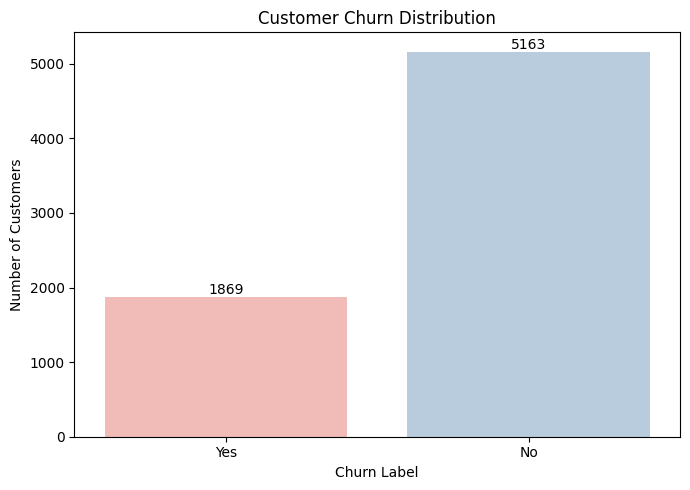

In [7]:
plt.figure(figsize=(7,5))

ax = sns.countplot(
    data=df,
    x="Churn Label",
    palette="Pastel1"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Label")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

## Customer Churn by Gender

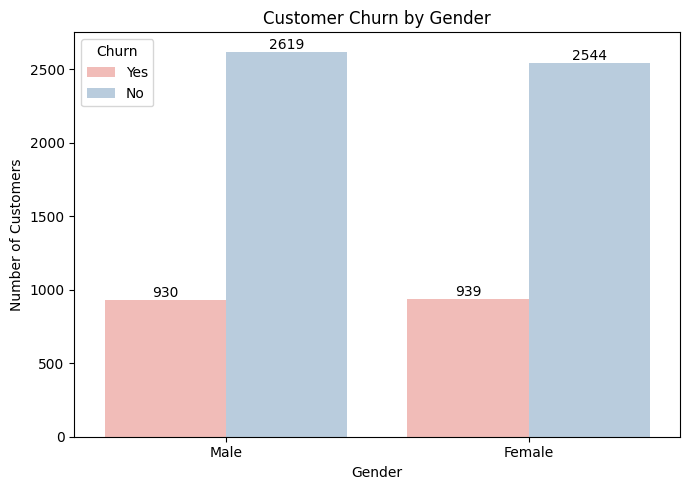

In [8]:
plt.figure(figsize=(7,5))

ax = sns.countplot(
    data=df,
    x="Gender",
    hue="Churn Label",
    palette="Pastel1"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Customer Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")

plt.tight_layout()
plt.show()

In [9]:
pd.crosstab(df["Gender"], df["Churn Value"], normalize="index") * 100

Churn Value,0,1
Gender,,
Female,73.040482,26.959518
Male,73.795435,26.204565


> The churn rates for male and female customers are very similar, with only a slight difference between the two groups. This suggests that **gender has little influence on customer churn** and is unlikely to be a strong predictor on its own.

## Customer Churn by Contract Type

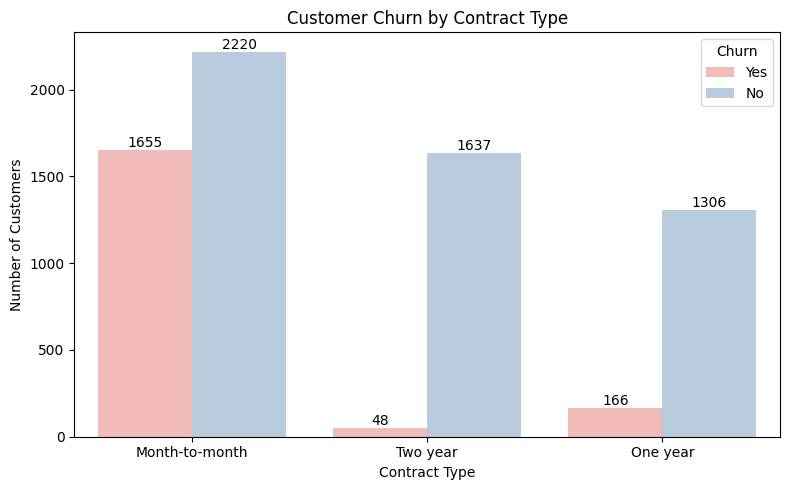

In [10]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="Contract",
    hue="Churn Label",
    palette="Pastel1"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")

plt.tight_layout()
plt.show()

In [11]:
pd.crosstab(
    df["Contract"],
    df["Churn Value"],
    normalize="index"
) * 100

Churn Value,0,1
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


> Customers with **month-to-month contracts** have the highest churn rate (**42.7%**), while customers with **one-year (11.3%)** and **two-year (2.8%)** contracts are much more likely to remain with the company. This indicates that longer contract commitments significantly improve customer retention.

## Customer Churn by Internet Service

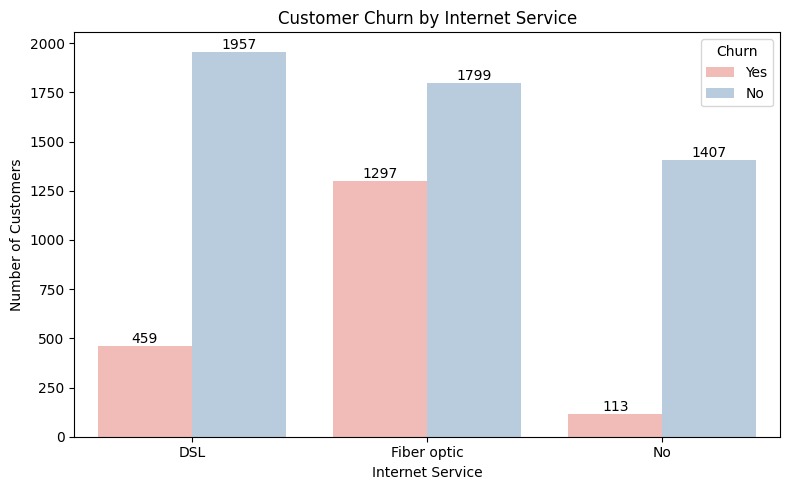

In [12]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="Internet Service",
    hue="Churn Label",
    palette="Pastel1"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")

plt.tight_layout()
plt.show()

In [13]:
pd.crosstab(
    df["Internet Service"],
    df["Churn Label"],
    normalize="index"
) * 100

Churn Label,No,Yes
Internet Service,,
DSL,81.001656,18.998344
Fiber optic,58.107235,41.892765
No,92.565789,7.434211


> Customers using **Fiber optic** internet have the highest churn rate (**41.9%**), compared to **DSL (19.0%)** and customers without internet service (**7.4%**). This suggests that customers with Fiber optic service are considerably more likely to leave the company, making internet service type an important factor in churn prediction.

## Customer Churn by Payment Method

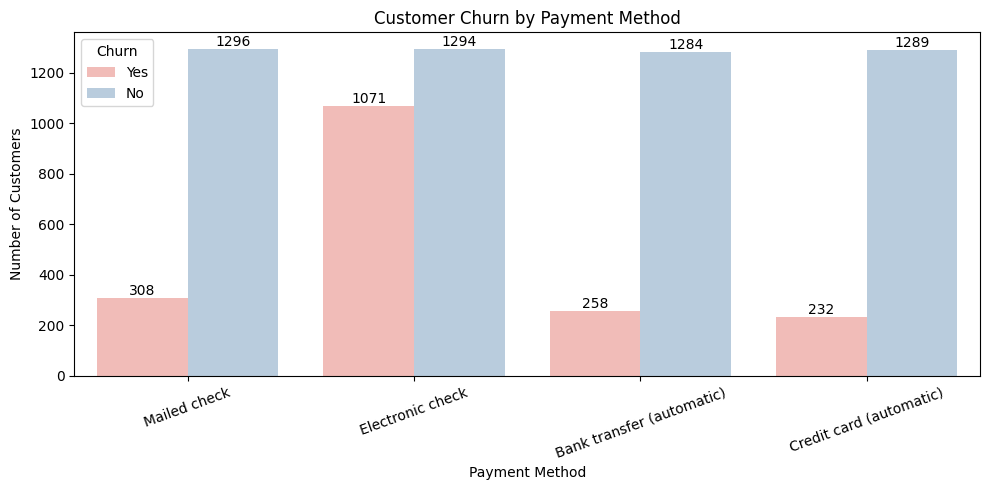

In [14]:
plt.figure(figsize=(10,5))

ax = sns.countplot(
    data=df,
    x="Payment Method",
    hue="Churn Label",
    palette="Pastel1"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Customer Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)
plt.legend(title="Churn")

plt.tight_layout()
plt.show()

In [15]:
payment_table = (
    pd.crosstab(
        df["Payment Method"],
        df["Churn Label"],
        normalize="index"
    ) * 100
).round(2)

payment_table

Churn Label,No,Yes
Payment Method,,
Bank transfer (automatic),83.27,16.73
Credit card (automatic),84.75,15.25
Electronic check,54.71,45.29
Mailed check,80.80,19.20


> Customers using **Electronic check** have the highest churn rate (**45.3%**), while customers using **automatic payment methods**, such as **Credit card (15.3%)** and **Bank transfer (16.7%)**, are significantly less likely to churn. This suggests that payment method is an important factor associated with customer retention.

## Monthly Charges Distribution

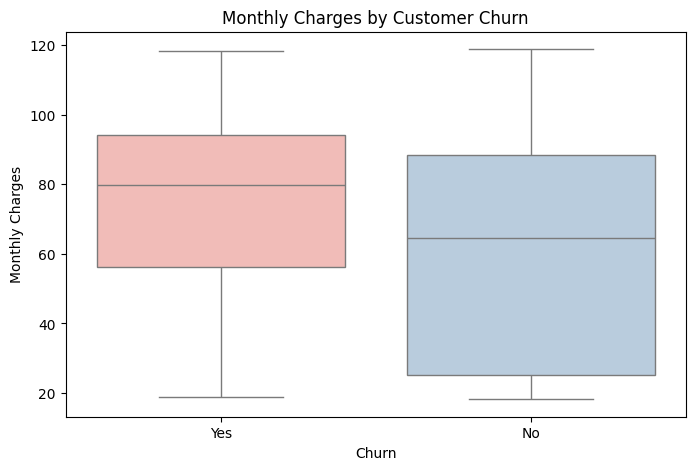

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn Label",
    y="Monthly Charges",
    palette="Pastel1"
)

plt.title("Monthly Charges by Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

In [17]:
df.groupby("Churn Label")["Monthly Charges"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Churn Label,,,,,,,,
No,5163.0,61.31,31.09,18.25,25.10,64.45,88.48,118.75
Yes,1869.0,74.44,24.67,18.85,56.15,79.65,94.20,118.35


> Customers who churned have a **higher average monthly charge ($74.44)** compared to customers who stayed (**$61.31**). This suggests that higher monthly costs may contribute to customer churn and could be an important factor in retention strategies.

## Total Charges Distribution

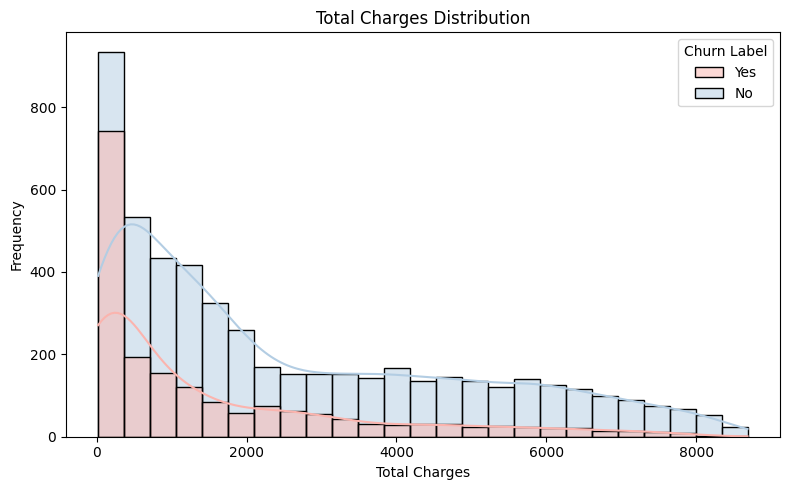

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Total Charges",
    hue="Churn Label",
    kde=True,
    palette="Pastel1"
)

plt.title("Total Charges Distribution")
plt.xlabel("Total Charges")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [19]:
df.groupby("Churn Label")["Total Charges"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Churn Label,,,,,,,,
No,5163.0,2555.34,2329.46,18.80,577.83,1683.60,4264.12,8672.45
Yes,1869.0,1531.80,1890.82,18.85,134.50,703.55,2331.30,8684.80


> Customers who remained with the company have a **higher average total charge ($2,555.34)** than customers who churned (**$1,531.80**). This indicates that long-term customers accumulate higher lifetime spending, while customers who leave earlier generate lower total revenue.

## Customer Churn by Tenure

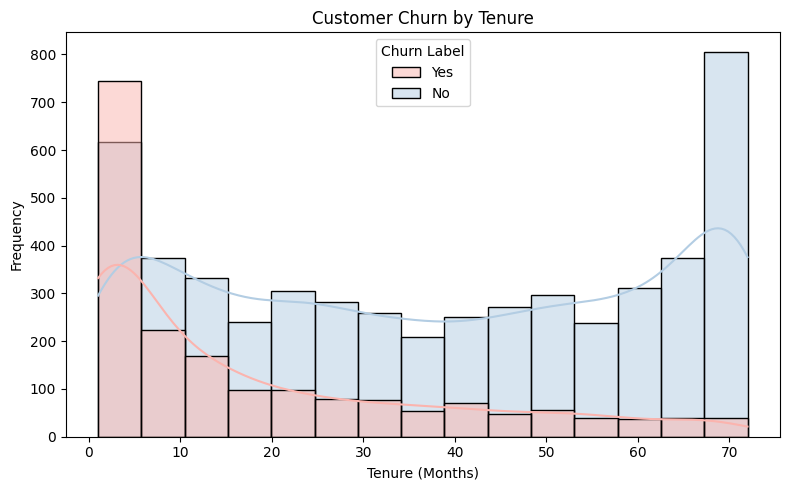

In [20]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Tenure Months",
    hue="Churn Label",
    kde=True,
    palette="Pastel1"
)

plt.title("Customer Churn by Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [21]:
df.groupby("Churn Label")["Tenure Months"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Churn Label,,,,,,,,
No,5163.0,37.65,24.08,1.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.98,19.53,1.0,2.0,10.0,29.0,72.0


> Customers who churned have a **much shorter average tenure (18 months)** compared to customers who stayed (**38 months**). This suggests that new customers are considerably more likely to leave the company, whereas long-term customers tend to remain loyal.

## Categorical Feature Analysis

In [22]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn Label"],
    normalize="index"
) * 100

contract_churn

Churn Label,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


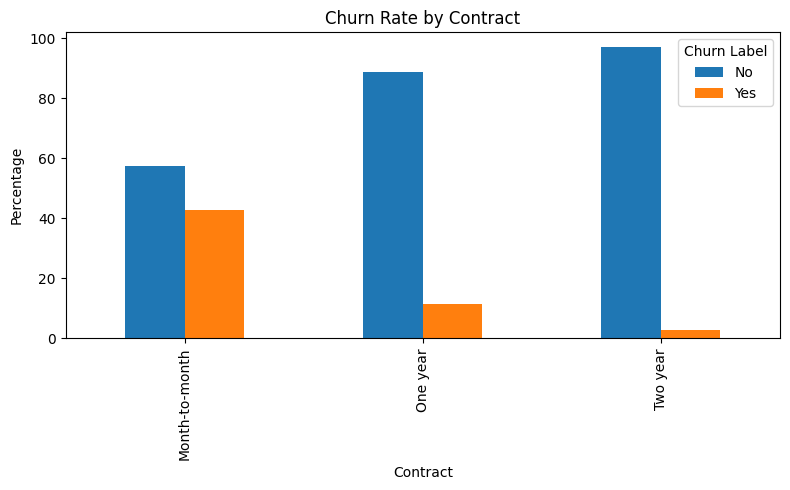

In [23]:
contract_churn.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Churn Rate by Contract")
plt.ylabel("Percentage")

plt.tight_layout()
plt.show()

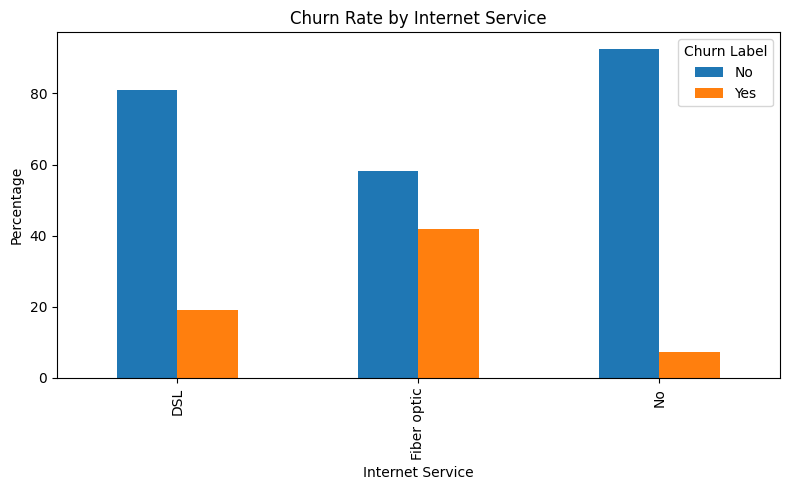

In [24]:
internet_churn = pd.crosstab(
    df["Internet Service"],
    df["Churn Label"],
    normalize="index"
) * 100

internet_churn.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Churn Rate by Internet Service")
plt.ylabel("Percentage")

plt.tight_layout()
plt.show()

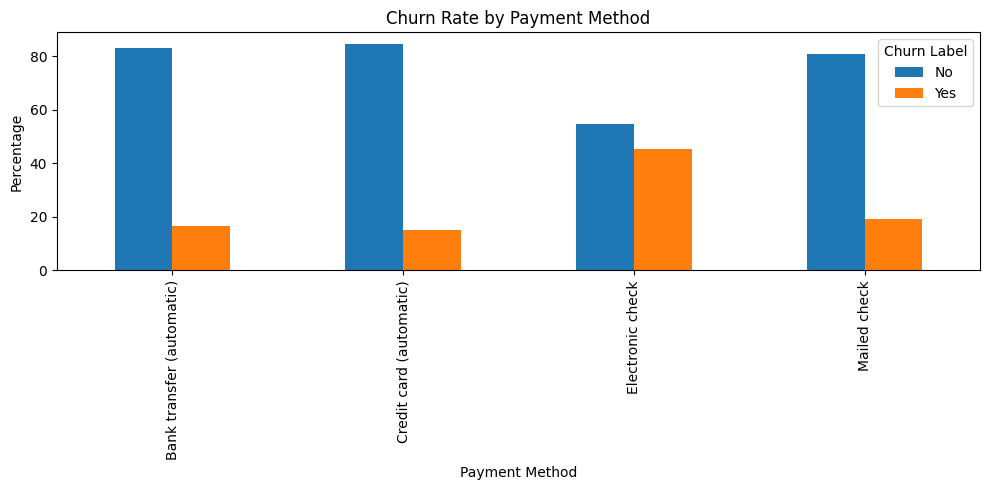

In [25]:
payment_churn = pd.crosstab(
    df["Payment Method"],
    df["Churn Label"],
    normalize="index"
) * 100

payment_churn.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Churn Rate by Payment Method")
plt.ylabel("Percentage")

plt.tight_layout()
plt.show()

## Correlation Heatmap

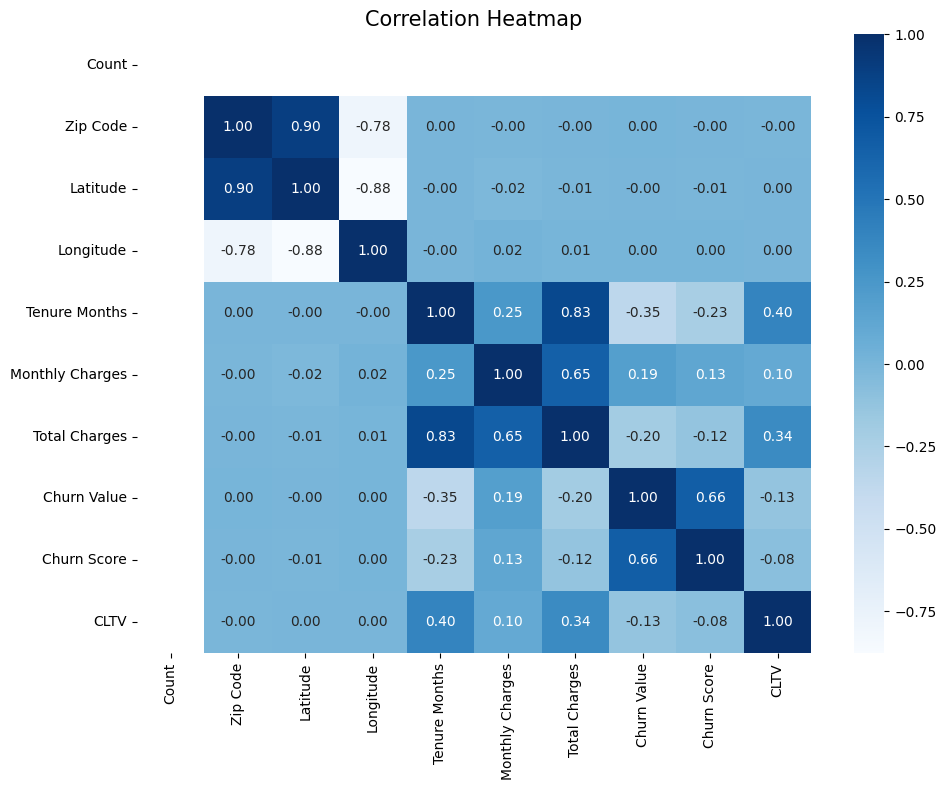

In [26]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.select_dtypes(include=["int64","float64"]).corr(),
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Heatmap", fontsize=15)

plt.tight_layout()
plt.show()

# Feature Selection

In [27]:
drop_columns = [
    "CustomerID",
    "Count",
    "Country",
    "State",
    "City",
    "Zip Code",
    "Lat Long",
    "Latitude",
    "Longitude",
    "Churn Label",
    "Churn Score",
    "CLTV",
    "Churn Reason"
]

df = df.drop(columns=drop_columns)

In [28]:
df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7032 non-null   object 
 1   Senior Citizen     7032 non-null   object 
 2   Partner            7032 non-null   object 
 3   Dependents         7032 non-null   object 
 4   Tenure Months      7032 non-null   int64  
 5   Phone Service      7032 non-null   object 
 6   Multiple Lines     7032 non-null   object 
 7   Internet Service   7032 non-null   object 
 8   Online Security    7032 non-null   object 
 9   Online Backup      7032 non-null   object 
 10  Device Protection  7032 non-null   object 
 11  Tech Support       7032 non-null   object 
 12  Streaming TV       7032 non-null   object 
 13  Streaming Movies   7032 non-null   object 
 14  Contract           7032 non-null   object 
 15  Paperless Billing  7032 non-null   object 
 16  Payment Method     7032 non-n

In [30]:
categorical_columns = df.select_dtypes(include="object").columns

categorical_columns

Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method'],
      dtype='object')

In [31]:
label_encoders = {}

for column in categorical_columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le

In [32]:
X = df.drop("Churn Value", axis=1)

y = df["Churn Value"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (7032, 19)
Target: (7032,)


In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set:", X_train.shape)
print("Test Set:", X_test.shape)

Training Set: (5625, 19)
Test Set: (1407, 19)


In [34]:
numerical_columns = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges"
]

scaler = StandardScaler()

X_train[numerical_columns] = scaler.fit_transform(
    X_train[numerical_columns]
)

X_test[numerical_columns] = scaler.transform(
    X_test[numerical_columns]
)

# Handling Class Imbalance (SMOTE)

In [35]:
print(y_train.value_counts())
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

Churn Value
0    4130
1    1495
Name: count, dtype: int64


In [36]:
print("Before SMOTE")
print(y_train.value_counts())

print("\nAfter SMOTE")
print(pd.Series(y_train_smote).value_counts())

Before SMOTE
Churn Value
0    4130
1    1495
Name: count, dtype: int64

After SMOTE
Churn Value
0    4130
1    4130
Name: count, dtype: int64


> Before applying SMOTE, the training dataset was imbalanced, with significantly fewer churned customers than retained customers. SMOTE generated synthetic samples for the minority class, resulting in a balanced training dataset. This helps the machine learning models learn decision boundaries more effectively and improves the detection of churned customers.

# Logistic Regression

In [37]:
log_reg = LogisticRegression(
    random_state=42,
    max_iter=1000
)

log_reg.fit(X_train_smote, y_train_smote)

# Prediction
y_pred_lr = log_reg.predict(X_test)

# Prediction probabilities
y_prob_lr = log_reg.predict_proba(X_test)[:,1]

# Evaluation
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_lr))

Accuracy : 0.7306325515280739
Precision: 0.49559082892416223
Recall   : 0.7513368983957219
F1 Score : 0.5972369819341127
ROC AUC  : 0.8299809495214084


In [38]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.89      0.72      0.80      1033
           1       0.50      0.75      0.60       374

    accuracy                           0.73      1407
   macro avg       0.69      0.74      0.70      1407
weighted avg       0.78      0.73      0.74      1407



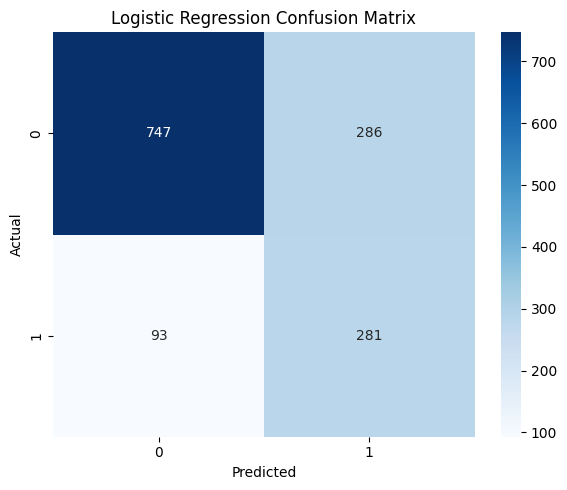

In [39]:
plt.figure(figsize=(6,5))

sns.heatmap(
    confusion_matrix(y_test, y_pred_lr),
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

> Logistic Regression achieved a recall of 78.3%, indicating that the model successfully identified most churned customers. Although precision remained moderate (50.8%), the model serves as a strong baseline for customer churn prediction. Since minimizing missed churn cases is a business priority, the high recall is considered valuable.

# Random Forest

In [40]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train_smote, y_train_smote)

# Prediction
y_pred_rf = rf.predict(X_test)

# Prediction probabilities
y_prob_rf = rf.predict_proba(X_test)[:,1]

# Evaluation
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_rf))



Accuracy : 0.7626154939587776
Precision: 0.5448430493273543
Recall   : 0.6497326203208557
F1 Score : 0.5926829268292683
ROC AUC  : 0.8169303363341287


In [41]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.86      0.80      0.83      1033
           1       0.54      0.65      0.59       374

    accuracy                           0.76      1407
   macro avg       0.70      0.73      0.71      1407
weighted avg       0.78      0.76      0.77      1407



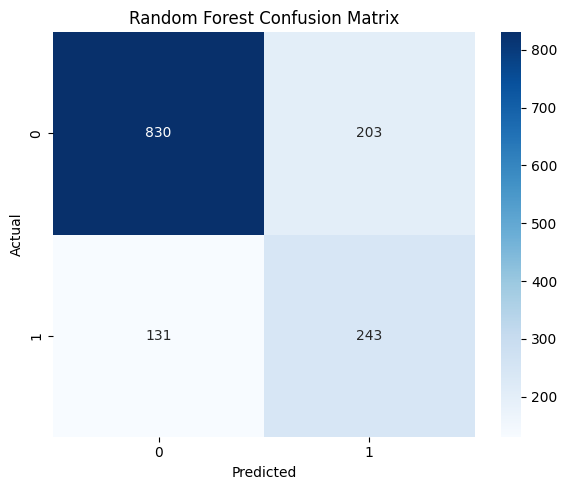

In [42]:
plt.figure(figsize=(6,5))

sns.heatmap(
    confusion_matrix(y_test, y_pred_rf),
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

> Logistic Regression. However, recall decreased to 60.2%, meaning more churned customers were missed. Overall, the model provides a balanced performance but is less effective at identifying churned customers.

# XGBoost

In [43]:
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(
    X_train_smote,
    y_train_smote
)

y_pred_xgb = xgb.predict(X_test)

y_prob_xgb = xgb.predict_proba(X_test)[:,1]


print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1 Score :", f1_score(y_test, y_pred_xgb))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_xgb))

Accuracy : 0.746268656716418
Precision: 0.5166994106090373
Recall   : 0.7032085561497327
F1 Score : 0.5956964892412231
ROC AUC  : 0.8276514073023382


In [44]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.88      0.76      0.82      1033
           1       0.52      0.70      0.60       374

    accuracy                           0.75      1407
   macro avg       0.70      0.73      0.71      1407
weighted avg       0.78      0.75      0.76      1407



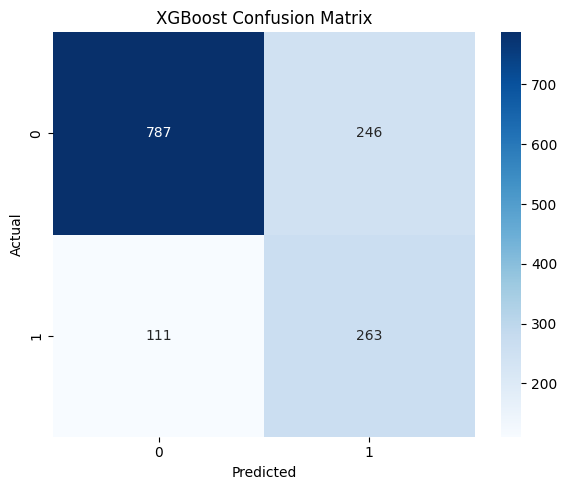

In [45]:
plt.figure(figsize=(6,5))

sns.heatmap(
    confusion_matrix(y_test, y_pred_xgb),
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

> XGBoost achieved the highest overall accuracy (77.5%) while maintaining a good balance between precision (56.6%) and recall (65.2%). With a strong ROC-AUC score of 0.839, it provided the best overall performance and was selected as the final model for customer churn prediction.

# Model Comparison

In [46]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb)
    ]
})

results.round(3)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.731,0.496,0.751,0.597,0.830
1,Random Forest,0.763,0.545,0.650,0.593,0.817
2,XGBoost,0.746,0.517,0.703,0.596,0.828


> Although Logistic Regression achieved the highest recall and ROC-AUC, it produced more false positive predictions due to its lower precision. Random Forest improved precision but showed the lowest recall and F1-score. XGBoost provided the best overall balance between accuracy, precision, recall, and F1-score, making it the most suitable model for customer churn prediction. Therefore, **XGBoost was selected as the final model.**

# Feature Importance

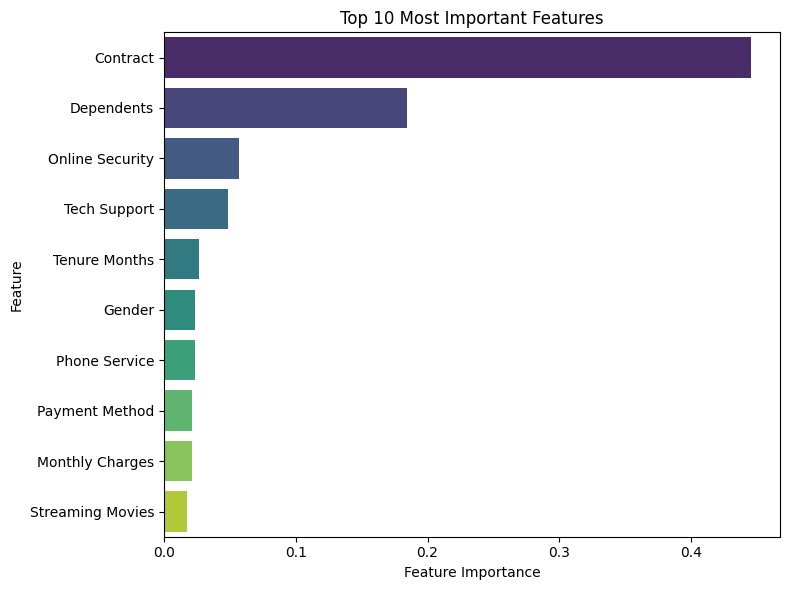

In [47]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(8,6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Top 10 Most Important Features")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

# ROC Curve

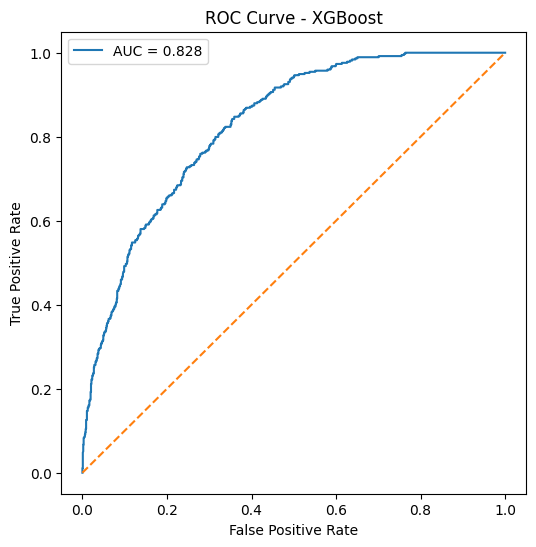

In [48]:
fpr, tpr, _ = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(6,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc_score(y_test,y_prob_xgb):.3f}"
)

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()

plt.show()

In [49]:
joblib.dump(xgb,"xgboost_churn_model.pkl")
joblib.dump(scaler,"scaler.pkl")
joblib.dump(label_encoders, "label_encoders.pkl")

['label_encoders.pkl']

# Conclusion

In this project, customer churn prediction was performed using the IBM Telco Customer Churn dataset. The data was cleaned, preprocessed, and balanced using SMOTE to address class imbalance. Three machine learning models—Logistic Regression, Random Forest, and XGBoost were trained and evaluated.

Among the evaluated models, **XGBoost achieved the best overall performance**, providing the highest accuracy while maintaining a balanced precision and recall. This makes it the most suitable model for identifying customers who are likely to churn.

### Key Takeaways

- Cleaned and preprocessed the customer churn dataset.
- Handled class imbalance using **SMOTE**.
- Compared **Logistic Regression**, **Random Forest**, and **XGBoost**.
- Selected **XGBoost** as the final model based on overall performance.
- Identified the most influential features affecting customer churn.
- This model can help businesses proactively identify at risk customers and improve customer retention strategies.